<a href="https://colab.research.google.com/github/monicaillner/cap-comp215-mi/blob/main/comp215_project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Langton's Ant

 **By Monica Illner and Vignesh Mahajan**

"Langton's ant is a two-dimensional Turing machine with a very simple set of rules but complex emergent behavior. It was invented by Chris Langton in 1986 and runs on a square lattice of black and white cells.[1] The idea has been generalized in several different ways, such as turmites which add more colors and more states." - Wikipedia

Sources: ChatGPT, https://en.wikipedia.org/wiki/Langton%27s_ant, Lab 6, Lab 7

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import animation
import time
import pprint

matplotlib.rc('animation', html='jshtml')

# Helper Functions

Copied from Lab 7 - Forest Fire.

In [4]:
def plot_2d_array(array, axes=None, title='', cmap='binary', **options):    # cmap changed to 'binary' since grid has only two states
    """
    Plot the 2D array as an image on the given axes  1's will be dark blue, 0's will be light blue.

    :param axes: the axes to plot on, or None to use the `plt.gca()` (current axes)
    :param options: keyword arguments passed directly to `plt.imshow()`
           see https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html
    """
    axes = axes or plt.gca()  # If not axes are provided, draw on current axes
    axes.set_title(title)
    # Turn off axes labels and tick marks
    axes.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False ,
                     labelbottom=False, labeltop=False, labelleft=False, labelright=False,)
    # Defaults for displaying a "matrix" with hard-pixel boundaries and (0,0) at top-left
    options = {**dict(interpolation='nearest', origin='upper'), **options}
    axes.imshow(array, cmap=cmap, **options)

In [5]:
class Animation2D:
    """
      Animates any 2D model with a step() method and a draw() method, using matplotlib
      model.step() should take no parameters - just step the model forward one step.
      model.draw() should take 2 parameters, the matpltolib axes to draw on and an integer step number

      See https://www.allendowney.com/blog/2019/07/25/matplotlib-animation-in-jupyter/
          for a discussion of the pros and cons of various animation techniques in jupyter notebooks
    """

    def __init__(self, model, frames=50, steps_per_frame=1, figsize=(8, 8)):
        """
        :param model: the simulation object to animate, with step() and draw(axes, step) methods
        :param frames: number of animation frames to generate
        """
        self.model = model
        self.frames = frames
        self.steps_per_frame = steps_per_frame
        self.fig, self.ax = plt.subplots(figsize=figsize)

    def animation_step(self, step):
        """ Step the model forward and draw the plot """
        if step > 0:
            for _ in range(self.steps_per_frame):
                self.model.step()
        self.model.draw(self.ax, step=step * self.steps_per_frame)

    def show(self):
        """ return the matplotlib animation object, ready for display """
        anim = animation.FuncAnimation(self.fig, self.animation_step, frames=self.frames)
        plt.close()  # this ensures the last frame is not shown as a separate plot
        return anim

    def animate(self, interval=None):
        """ Animate the model simulation directly in the notebook display block """
        from IPython.display import clear_output
        try:
            for i in range(self.frames):
                clear_output(wait=True)  # clear the IPython display
                self.ax.clear()  # clear old image from the axes (fixes a performance issue)
                plt.figure(self.fig)  # add the figure back to pyplot ** sigh **
                self.animation_step(i)
                plt.show()  # show the current animation frame (pyplot then closes and throws away figure ** sigh **)
                if interval:
                    time.sleep(interval)
        except KeyboardInterrupt:
            pass

# Langton's Ant Class

**Rules applied in step function**

*Part 1 - Current State of Ant:*

There are four possible directions for the ant to go; up (0), right (1), down (2), and left (3) and two possible states of the grid; white and black.

There are two cases. If the ant lands on a white square or a black square.

If the square is white, the rule is to turn right and to change the colour to black.

To change the direction of the ant, we applied `(self.direction + 1) % 4`

The ant is turning right, so we added one. Since the directions ranged from 1-4, we used % 4 to wrap around to get the value of the direction.

For example if the ant was facing left (3), then (3 + 1) % 4 = 0, and the ant would go up.

We used a similar rule if the ant was on a black square, but used (self.direction - 1) % 4 since the ant is going the opposite direction.

*Part 2 - Ant Movement:*

After the ant has turned, it moves forward one square. Based on the direction of the movement, a row or column will increase or decrease.

`% self.n` prevents the ant from moving off the grid and index errors.


In [10]:
class LangtonsAnt:
    """
    2D CA model of Langton's Ant.
    """

    # Possible cell states
    EMPTY = 0   # white
    FILLED = 1  # black

    def __init__(self, n, start_row=None, start_col=None):
        """
        Initialize the grid and ant.

        n: grid size (n x n), int
        start_row: initial row of the ant, defaults to center, int
        start_col: initial column, defaults to center, int
        """

        self.n = n
        self.state = np.zeros((n, n), dtype=int)  # initializes grid of an n x n size

        # Ant will start at the center if no row/ column is given
        if start_row is None:
            start_row = n // 2
        if start_col is None:
            start_col = n // 2

        # Ant position
        self.row = start_row
        self.col = start_col

        self.direction = 0  # 0=up, 1=right, 2=down, 3=left
        self.time = 0

    def step(self):
        """ Executes one time step, please see above explaination of rules. """

        # Checks current state where ant is
        if self.state[self.row, self.col] == self.EMPTY:
            self.direction = (self.direction + 1) % 4   # rule applied
            self.state[self.row, self.col] = self.FILLED
        else:
            self.direction = (self.direction - 1) % 4   # rule applied
            self.state[self.row, self.col] = self.EMPTY

        # Ant moves forward
        if self.direction == 0:
            self.row = (self.row - 1) % self.n
        elif self.direction == 1:
            self.col = (self.col + 1) % self.n
        elif self.direction == 2:
            self.row = (self.row + 1) % self.n
        elif self.direction == 3:
            self.col = (self.col - 1) % self.n

        self.time += 1

    def run(self, steps):
        """ Runs simulation for given number of steps. """
        for _ in range(steps):
            self.step()

    def num_filled(self):
        """ Counts the number of filled cells on the grid. """
        return np.sum(self.state == self.FILLED)

    def pct_filled(self):
        """ Computes the proportion of filled cells on the grid. """
        return self.num_filled() / self.state.size

    def draw(self, axes=None, step=''):
        """ Draws the current state of the simulation """
        axes = axes or plt.gca()

        title = f"Time:{self.time} Black: {round(self.pct_filled() * 100, 2)}%"

        plot_2d_array(
            self.state,
            axes=axes,
            title=title,
            cmap='binary'
        )

        axes.plot(self.col, self.row, 'ro')

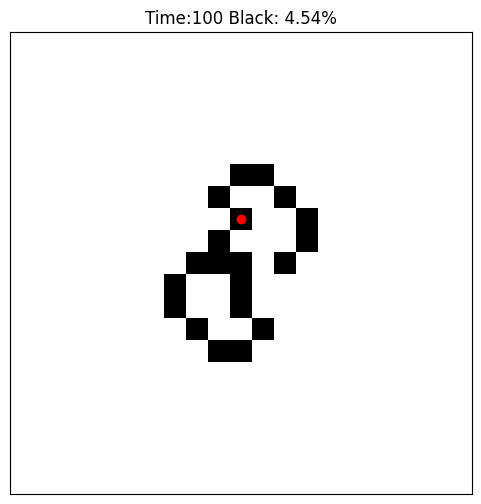

Time: 100
Position: (8, 10)
Direction: 0
Black cells: 20


In [11]:
# Test Block

m = LangtonsAnt(21)

m.run(100)

fig, ax = plt.subplots(figsize=(6, 6))
m.draw(ax)
plt.show()

print("Time:", m.time)
print("Position:", (m.row, m.col))
print("Direction:", m.direction)
print("Black cells:", m.num_filled())

# Simple Animation Block

To visualize Langton's Ant we used the `Animation2D class` from the Forest Fire lab.

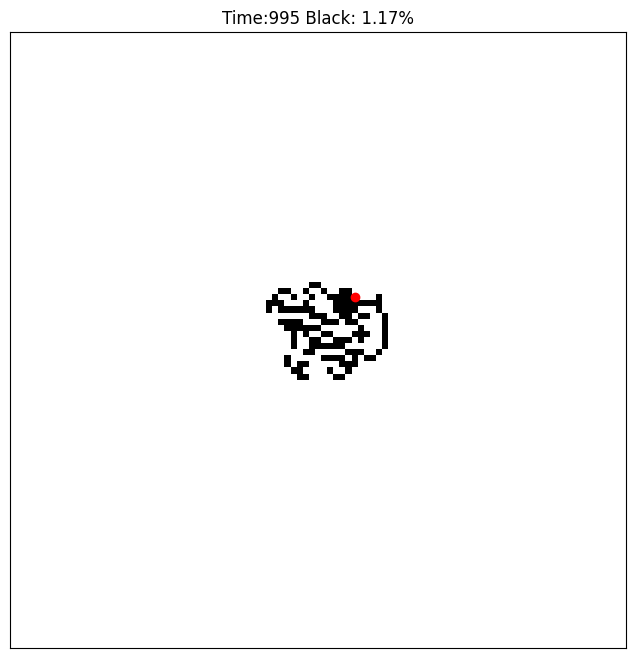

In [12]:
model = LangtonsAnt(101)

anim = Animation2D(model, frames=200, steps_per_frame=5)

anim.animate(interval=0.05)

# Experimenting The Affects of Starting Position

To investigate how starting position affects the behavior of Langton’s Ant, we ran the simulation with three different initial positions: the center of the grid, an upper-left position, and a lower-right position.

Each simulation used the same grid size and was run for 11,000 steps. The final states were then visualized side by side to compare the resulting patterns and number of black cells.

We had help from ChatGPT to create a figure with three side by side plots.

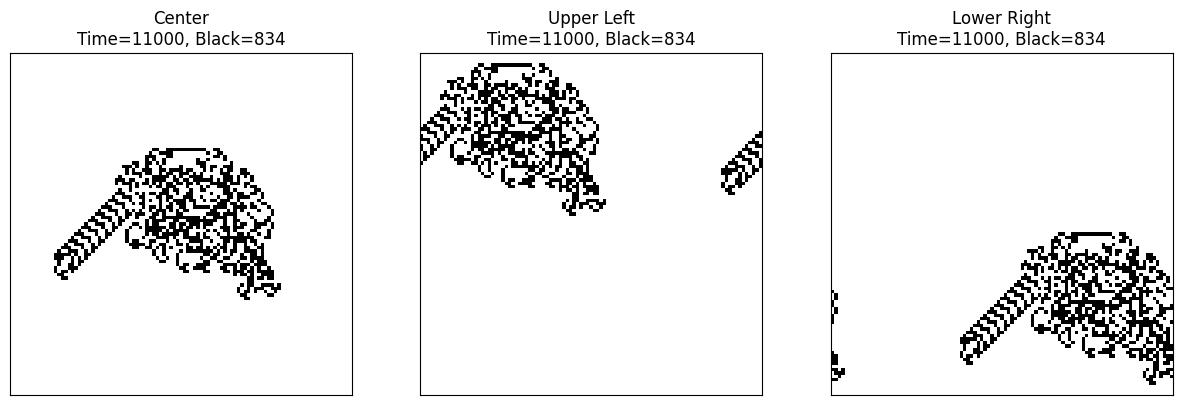

In [23]:
n = 101
steps = 11000

start_positions = [
    ("Center", 50, 50),
    ("Upper Left", 25, 25),
    ("Lower Right", 75, 75)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))   # Creates a figure with three plots (one row of three columns)

for ax, (label, r, c) in zip(axes, start_positions):  # Looped through different starting positions
    model = LangtonsAnt(n, start_row=r, start_col=c)
    model.run(steps)

    title=f"{label}\nTime={model.time}, Black={model.num_filled()}"

    plot_2d_array(
        model.state,
        axes=ax,
        cmap='binary',
        title=title
    )

plt.show()

In [24]:
results = []

for label, r, c in start_positions:
    model = LangtonsAnt(n, start_row=r, start_col=c)
    model.run(steps)

    results.append({
        "Start": label,
        "Final Row": int(model.row),
        "Final Col": int(model.col),
        "Black Cells": int(model.num_filled()),
        "Percent Black": float(round(model.pct_filled() * 100, 2))
    })

pprint.pprint(results)

[{'Black Cells': 834,
  'Final Col': 16,
  'Final Row': 64,
  'Percent Black': 8.18,
  'Start': 'Center'},
 {'Black Cells': 834,
  'Final Col': 92,
  'Final Row': 39,
  'Percent Black': 8.18,
  'Start': 'Upper Left'},
 {'Black Cells': 834,
  'Final Col': 41,
  'Final Row': 89,
  'Percent Black': 8.18,
  'Start': 'Lower Right'}]


# Experiment Results

The starting position of the ant changes the final location and placement of the pattern, but does not affect the number of black cells or the overall structure.
Therefore, the long-term dynamics of Langton's Ant are largely independent of the initial position.

# Behaviour from Increasing Steps

In the beginning (around 100 steps), the pattern is small and looks random. The ant moves in a way that is hard to predict.

As the number of steps increases (around 1000-5000 steps), the pattern becomes bigger and more complex. Groups of black and white cells start to form, but it still looks somewhat random.

After many steps (around 10000+ steps), a more structured pattern begins to appear. The ant starts forming repeating paths, or a "highway."

# Big-O Complexity

Each step of the simulation runs in constant time, O(1), because it only updates a single cell and the ant's position.

The time complexity depends on the number of steps, not the grid size. This means the time complexity is O(t), where t is number of steps.

Since the time complexity is O(t), the runtime increases linearly with the number of steps. This means that longer simulations will take proportionally more time to run. The grid size does not significantly affect runtime unless additional operations are performed on the entire grid.

Improvements to the code do not change Big-O complexity - they only make the simulation faster.

1000 steps -> 0.0008 seconds
5000 steps -> 0.0042 seconds
10000 steps -> 0.0121 seconds
20000 steps -> 0.0184 seconds


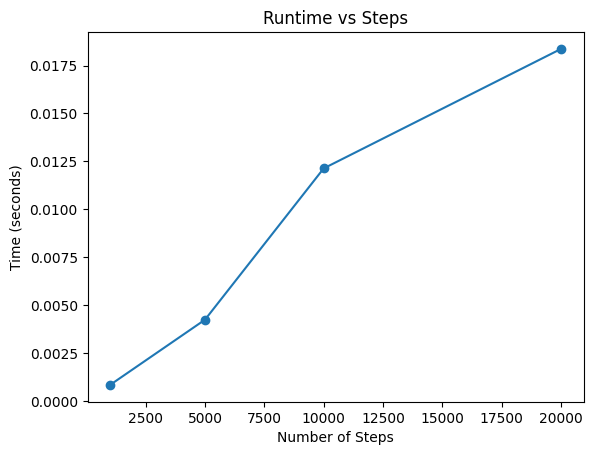

In [25]:
steps_list = [1000, 5000, 10000, 20000]
times = []

for steps in steps_list:
    model = LangtonsAnt(101)

    start = time.time()
    model.run(steps)
    end = time.time()

    elapsed = end - start
    times.append(elapsed)

    print(f"{steps} steps -> {elapsed:.4f} seconds")

plt.plot(steps_list, times, marker='o')
plt.xlabel("Number of Steps")
plt.ylabel("Time (seconds)")
plt.title("Runtime vs Steps")
plt.show()